# Demographic Segmentation

PPT:
Demographic segmentation, categorizing customers by age, occupation, or other attributes to reveal
different interaction patterns.

External Data Integration & Validation
- Source and integrate relevant external dataset (industry benchmarks, demographic census data, etc.)
- Validate findings against external sources
- Provide comparative context for customer behavior patterns
- Include data source credibility assessment

Geo-Spatial Insights
- Incorporate mapping of routes, hubs, and customer origins/destinations.
- Visualize geographic concentration of loyalty members.
- Relate geographic differences to potential segmentation variables.


🎯 Goal

Group customers based on who they are — their socio-demographic and lifestyle profile.
👉 This answers:

“What customer types make up our user base?”
“Which demographic groups show higher loyalty or profitability?”

🧩 Main Variables to Analyze

From CustomerDB mainly:

Age (if available or derived)

Gender

Education

MaritalStatus

Income

LocationCode (Urban/Suburban/Rural)

Country, Province, City

Engineered features:

Feature	Meaning
IncomeBracket	Categorized income levels
GeoRegion	Grouping by continent / region
EducationLevelEncoded	Numerical coding for clustering

In [13]:
# --- Standard Imports
import os
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.express as px
import geopandas as gpd

In [2]:
# directory with agregated dataset
data_dir = Path("../data/aggregated/")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['customers_aggregations - See.csv', 'customers_aggregations.csv']


In [3]:
# specify the files we want to load

dataset = data_dir / "customers_aggregations.csv"

# load them with pandas
dataset = pd.read_csv(dataset)

print("dataset shape:", dataset.shape)

dataset shape: (16574, 31)


In [4]:
# display the first few rows of the dataframe
display(dataset.head(3))

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,EndDate,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,points_redemption_ratio,companion_flight_ratio
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,...,2025-10-12,2431,184,53,507054.9,50699.39,13517.9,134.6,0.266628,0.288043
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,...,2025-10-12,2409,275,30,426827.4,42672.54,22457.8,221.4,0.526282,0.109091
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,...,2021-01-08,1274,116,37,238376.1,23832.41,5479.6,53.2,0.229922,0.318966


In [5]:
dataset.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate',
       'Customer Lifetime Value', 'EnrollmentType', 'IsActive', 'EndDate',
       'CustomerTenureDays', 'total_flights', 'total_flights_with_companions',
       'total_distance', 'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'points_redemption_ratio',
       'companion_flight_ratio'],
      dtype='object')

C:\Users\Duarte\AppData\Local\Temp\ipykernel_27300\366305558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x="Gender", palette="pastel", order=dataset["Gender"].value_counts().index)


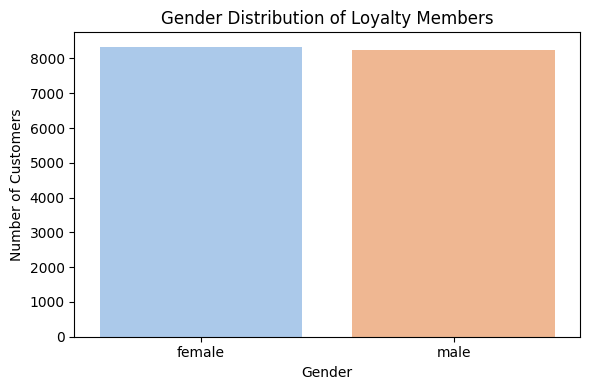


Gender distribution (%):
Gender
female    50.3
male      49.7
Name: proportion, dtype: float64


In [6]:
# Gender distirbution

plt.figure(figsize=(6,4))
sns.countplot(data=dataset, x="Gender", palette="pastel", order=dataset["Gender"].value_counts().index)
plt.title("Gender Distribution of Loyalty Members")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print("\nGender distribution (%):")
print((dataset["Gender"].value_counts(normalize=True) * 100).round(1))

C:\Users\Duarte\AppData\Local\Temp\ipykernel_27300\1555673567.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x="Education", order=order, palette="muted")


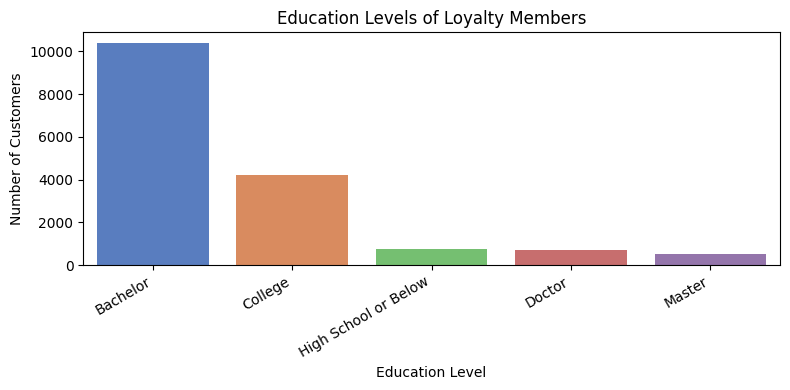


Education distribution (%):
Education
Bachelor                62.6
College                 25.3
High School or Below     4.7
Doctor                   4.4
Master                   3.0
Name: proportion, dtype: float64


In [7]:
# Education distibution

plt.figure(figsize=(8,4))
order = dataset["Education"].value_counts().index  # sort by most frequent
sns.countplot(data=dataset, x="Education", order=order, palette="muted")
plt.title("Education Levels of Loyalty Members")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nEducation distribution (%):")
print((dataset["Education"].value_counts(normalize=True) * 100).round(1))

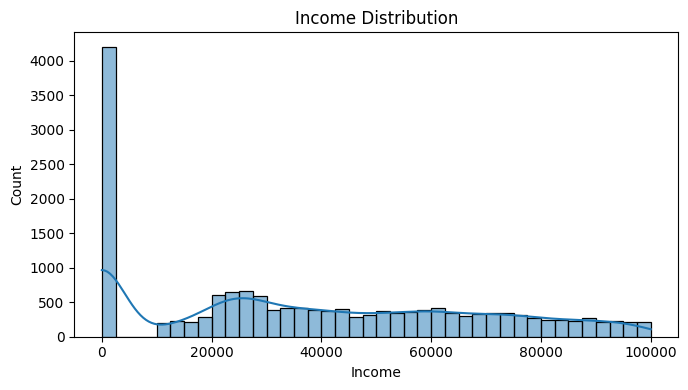

Income summary:
          Income
count  16574.00
mean   37739.99
std    30355.91
min        0.00
10%        0.00
25%        0.00
50%    34137.00
75%    62373.75
90%    81946.40
95%    90330.00
max    99981.00


In [8]:
# Income distribution

plt.figure(figsize=(7,4))
sns.histplot(dataset["Income"].dropna(), bins=40, kde=True)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

desc = dataset["Income"].describe(percentiles=[.1,.25,.5,.75,.9,.95]).to_frame("Income").round(2)
print("Income summary:\n", desc)

C:\Users\Duarte\AppData\Local\Temp\ipykernel_27300\985453244.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x="Marital Status", palette="pastel", order=dataset["Marital Status"].value_counts().index)


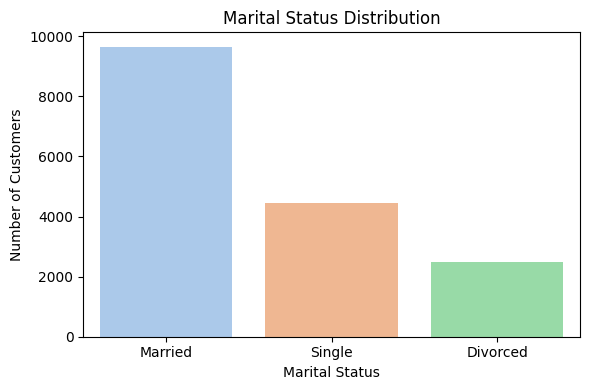


Marital Status (%):
Marital Status
Married     58.2
Single      26.8
Divorced    15.0
Name: proportion, dtype: float64


In [9]:
# Marital Status

plt.figure(figsize=(6,4))
sns.countplot(data=dataset, x="Marital Status", palette="pastel", order=dataset["Marital Status"].value_counts().index)
plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print("\nMarital Status (%):")
print((dataset["Marital Status"].value_counts(normalize=True) * 100).round(1))

In [27]:
# Province counts
prov_counts = (
    dataset["Province or State"]
    .value_counts(dropna=False)
    .rename_axis("Province")
    .reset_index(name="CustomerCount")
)
print(prov_counts.head(10))

# City counts (ranked)
city_counts = (
    dataset.groupby(["Province or State", "City"])
    .size()
    .reset_index(name="CustomerCount")
    .sort_values("CustomerCount", ascending=False)
)
print(city_counts.head(15))

           Province  CustomerCount
0           Ontario           5354
1  British Columbia           4333
2            Quebec           3245
3           Alberta            987
4          Manitoba            666
5     New Brunswick            629
6       Nova Scotia            529
7      Saskatchewan            404
8      Newfoundland            253
9             Yukon            108
   Province or State          City  CustomerCount
20           Ontario       Toronto           3323
6   British Columbia     Vancouver           2551
24            Quebec      Montreal           2028
10          Manitoba      Winnipeg            666
9   British Columbia      Whistler            579
14       Nova Scotia       Halifax            529
17           Ontario        Ottawa            505
2            Alberta      Edmonton            496
21           Ontario       Trenton            482
25            Quebec   Quebec City            472
4   British Columbia  Dawson Creek            434
11     New Brun

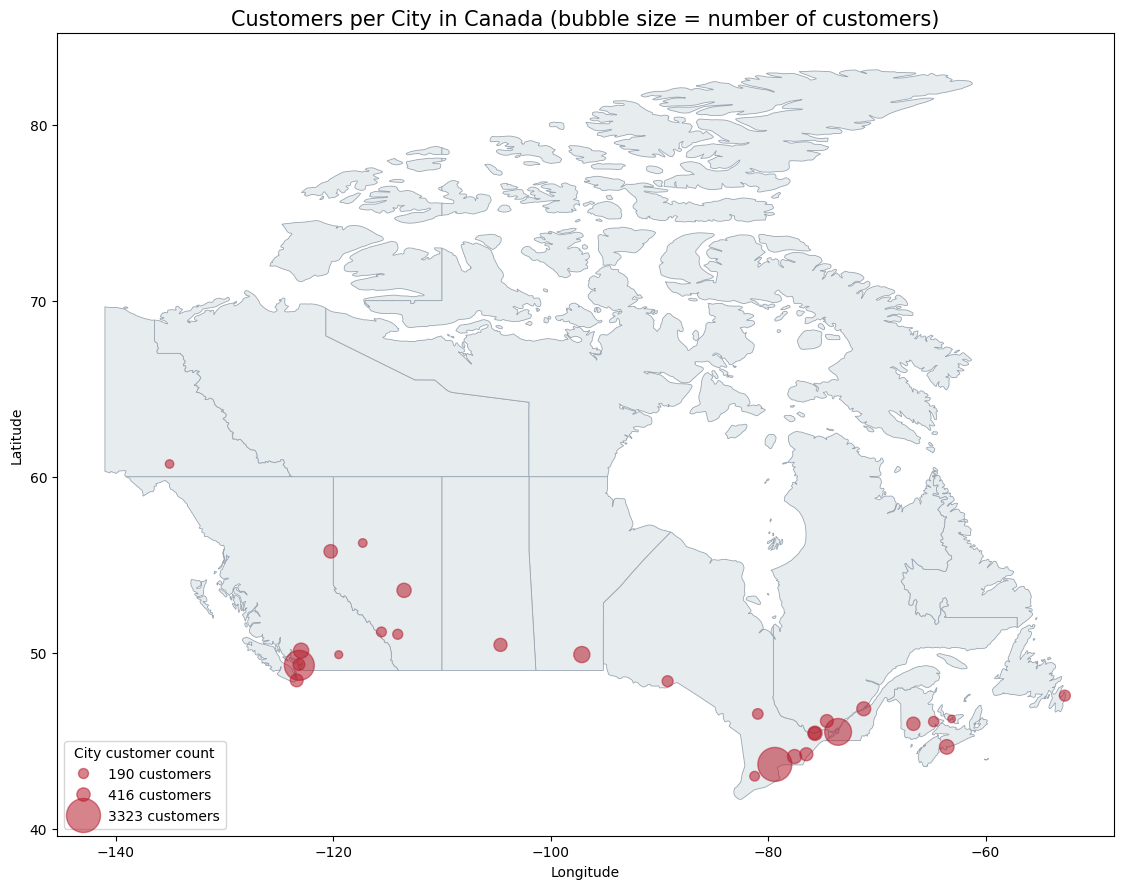

In [30]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1) Prepare data
df = dataset.copy()
df["Latitude"]  = pd.to_numeric(df["Latitude"],  errors="coerce")
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
df = df.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)

# Aggregate customers per city
city_agg = (
    df.groupby(["Province or State", "City"])
      .agg(CustomerCount=("City", "size"),
           Latitude=("Latitude", "mean"),
           Longitude=("Longitude", "mean"))
      .reset_index()
)

# 2) Canada provinces layer
admin1_url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
admin1 = gpd.read_file(admin1_url).to_crs("EPSG:4326")
canada_admin1 = admin1.loc[admin1["admin"] == "Canada", ["name", "geometry"]].copy()

# 3) GeoDataFrame for city bubbles
cities_gdf = gpd.GeoDataFrame(
    city_agg,
    geometry=gpd.points_from_xy(city_agg["Longitude"], city_agg["Latitude"]),
    crs="EPSG:4326"
)

# 4) Size scaling (scatter 's' is area in points^2)
counts = cities_gdf["CustomerCount"].astype(float).values
size_min, size_max = 30, 600  # adjust if needed
if counts.size > 0:
    cmin, cmax = counts.min(), counts.max()
    if cmin == cmax:
        sizes = np.full_like(counts, (size_min + size_max) / 2.0)
    else:
        sizes = np.interp(counts, (cmin, cmax), (size_min, size_max))
else:
    sizes = np.array([])

# 5) Plot
fig, ax = plt.subplots(figsize=(12, 9))
canada_admin1.plot(ax=ax, color="#E7ECEF", edgecolor="#9AA6B2", linewidth=0.6)

cities_gdf.plot(
    ax=ax,
    markersize=sizes,            # bubble sizes (area)
    color="#B61E2E",
    alpha=0.55
)

ax.set_title("Customers per City in Canada (bubble size = number of customers)", fontsize=15)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

# --- Custom bubble legend (robust across Matplotlib versions) ---
if counts.size > 0:
    # Choose representative counts (min, median, max or 3 quantiles)
    reps = np.unique(np.ceil(np.quantile(counts, [0.2, 0.6, 1.0])).astype(int))
    # Map those counts to scatter areas and then to Line2D marker sizes (radius ~ sqrt(area))
    rep_sizes = []
    for r in reps:
        if cmin == cmax:
            s = (size_min + size_max) / 2.0
        else:
            s = np.interp(r, (cmin, cmax), (size_min, size_max))
        rep_sizes.append(s)

    handles = [
        Line2D([0], [0],
               marker='o', linestyle='',
               markersize=np.sqrt(s),   # convert area to marker size
               markerfacecolor="#B61E2E", markeredgecolor="#B61E2E", alpha=0.55)
        for s in rep_sizes
    ]
    labels = [f"{int(r)} customers" for r in reps]
    ax.legend(handles, labels, title="City customer count", frameon=True, loc="lower left")

plt.tight_layout(); plt.show()



In [31]:
# Frequencies and % share
for col in ["LoyaltyStatus", "IsActive", "EnrollmentType"]:
    print(f"\n=== {col} (counts) ===")
    print(dataset[col].value_counts(dropna=False))
    print(f"\n=== {col} (%) ===")
    print((dataset[col].value_counts(normalize=True, dropna=False) * 100).round(1))


=== LoyaltyStatus (counts) ===
LoyaltyStatus
Star      7598
Nova      5611
Aurora    3365
Name: count, dtype: int64

=== LoyaltyStatus (%) ===
LoyaltyStatus
Star      45.8
Nova      33.9
Aurora    20.3
Name: proportion, dtype: float64

=== IsActive (counts) ===
IsActive
1    14327
0     2247
Name: count, dtype: int64

=== IsActive (%) ===
IsActive
1    86.4
0    13.6
Name: proportion, dtype: float64

=== EnrollmentType (counts) ===
EnrollmentType
Standard          15436
2021 Promotion     1138
Name: count, dtype: int64

=== EnrollmentType (%) ===
EnrollmentType
Standard          93.1
2021 Promotion     6.9
Name: proportion, dtype: float64


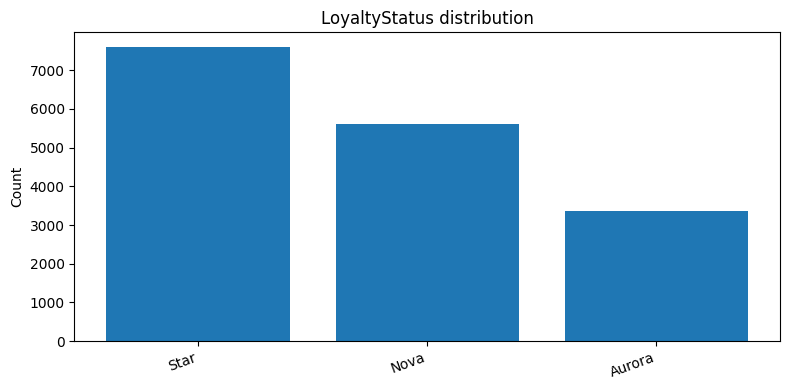

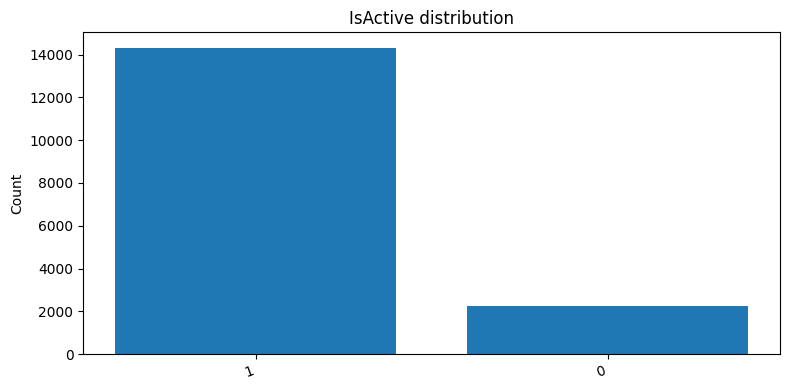

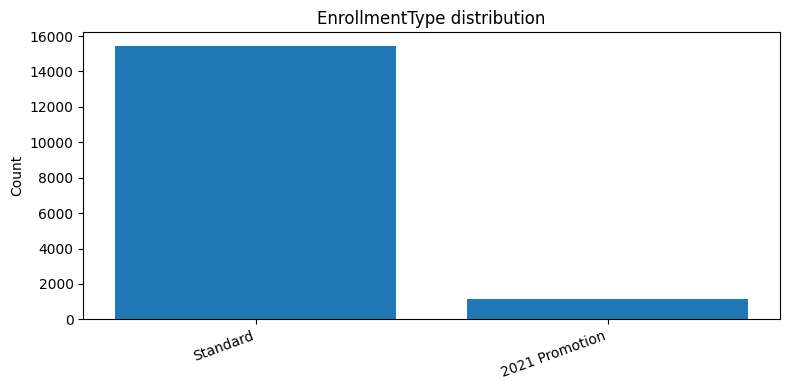

In [32]:
# Simple bar charts (one column at a time)

def bar_counts(df, col, top_n=None):
    counts = df[col].value_counts().head(top_n) if top_n else df[col].value_counts()
    plt.figure(figsize=(8,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"{col} distribution")
    plt.ylabel("Count"); plt.xticks(rotation=20, ha="right")
    plt.tight_layout(); plt.show()

bar_counts(dataset, "LoyaltyStatus")
bar_counts(dataset, "IsActive")
bar_counts(dataset, "EnrollmentType")

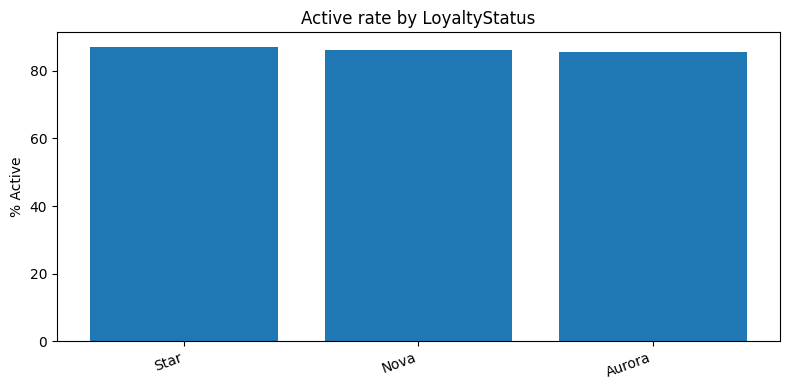

LoyaltyStatus
Star      87.1%
Nova      86.1%
Aurora    85.6%
Name: ActiveRate, dtype: object


In [33]:
# % Active by LoyaltyStatus (activation rate)

# If IsActive is booleans or {0,1}; coerce if needed
active_map = {True:1, False:0, "True":1, "False":0, "Y":1, "N":0, 1:1, 0:0}
tmp = dataset.copy()
tmp["IsActive_num"] = tmp["IsActive"].map(active_map)

active_rate = (
    tmp.groupby("LoyaltyStatus")["IsActive_num"]
       .mean()
       .sort_values(ascending=False)
       .rename("ActiveRate")
)

plt.figure(figsize=(8,4))
plt.bar(active_rate.index.astype(str), (active_rate.values*100))
plt.title("Active rate by LoyaltyStatus")
plt.ylabel("% Active"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

print(active_rate.mul(100).round(1).astype(str) + "%")

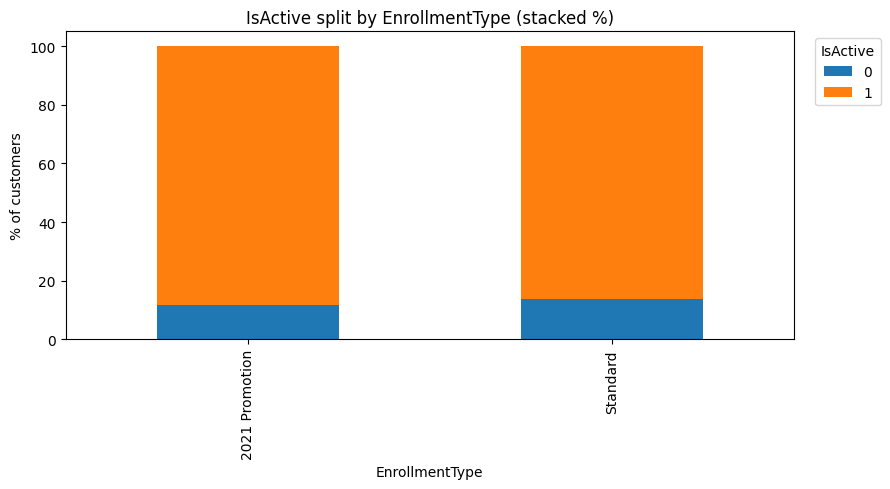


% breakdown by EnrollmentType:
IsActive           0     1
EnrollmentType            
2021 Promotion  11.7  88.3
Standard        13.7  86.3


In [34]:
# Stacked % bar: EnrollmentType × IsActive

ct = pd.crosstab(dataset["EnrollmentType"], dataset["IsActive"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked %
ax = ct_pct.plot(kind="bar", stacked=True, figsize=(9,5))
ax.set_title("IsActive split by EnrollmentType (stacked %)")
ax.set_ylabel("% of customers"); ax.set_xlabel("EnrollmentType")
ax.legend(title="IsActive", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

print("\n% breakdown by EnrollmentType:")
print(ct_pct.round(1))

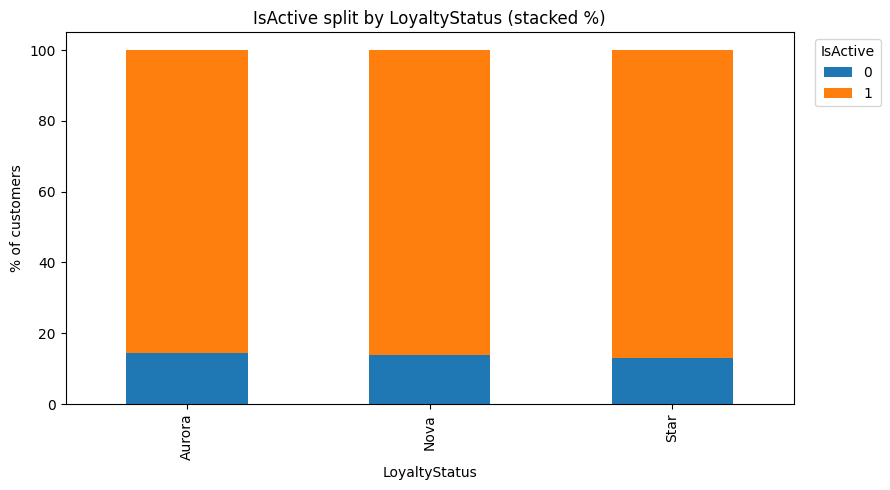


% breakdown by LoyaltyStatus:
IsActive          0     1
LoyaltyStatus            
Aurora         14.4  85.6
Nova           13.9  86.1
Star           12.9  87.1


In [35]:
# Stacked % bar: LoyaltyStatus × IsActive

ct2 = pd.crosstab(dataset["LoyaltyStatus"], dataset["IsActive"])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100

ax = ct2_pct.plot(kind="bar", stacked=True, figsize=(9,5))
ax.set_title("IsActive split by LoyaltyStatus (stacked %)")
ax.set_ylabel("% of customers"); ax.set_xlabel("LoyaltyStatus")
ax.legend(title="IsActive", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

print("\n% breakdown by LoyaltyStatus:")
print(ct2_pct.round(1))

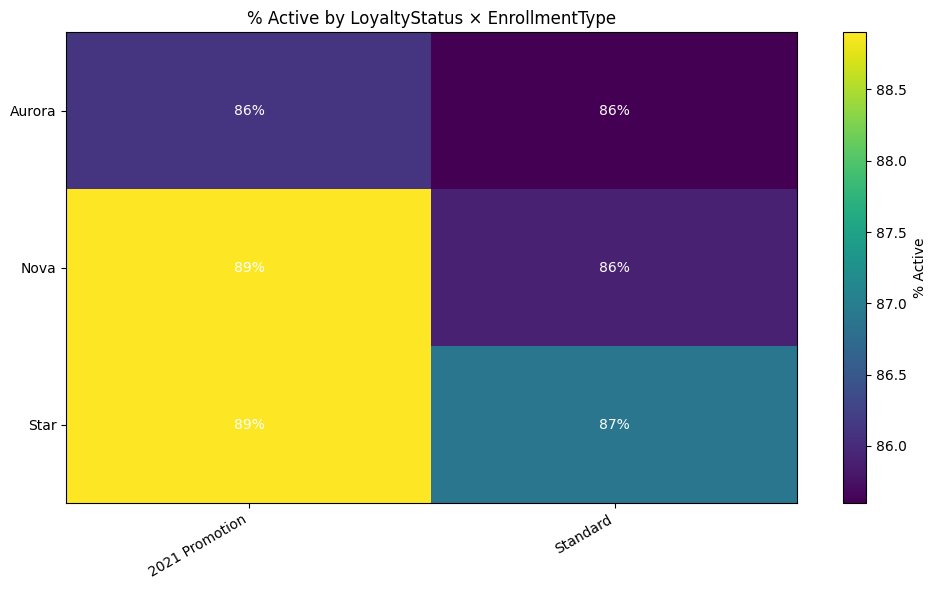


% Active (table):
EnrollmentType  2021 Promotion  Standard
LoyaltyStatus                           
Aurora                    86.1      85.6
Nova                      88.9      85.9
Star                      88.9      86.9


In [36]:
# Heatmap (matplotlib) of % Active for (LoyaltyStatus × EnrollmentType)

# Build % active pivot
active_map = {True:1, False:0, "True":1, "False":0, "Y":1, "N":0, 1:1, 0:0}
df = dataset.copy()
df["IsActive_num"] = df["IsActive"].map(active_map)

pivot = (
    df.pivot_table(
        index="LoyaltyStatus",
        columns="EnrollmentType",
        values="IsActive_num",
        aggfunc="mean"
    ) * 100
).round(1)

fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(pivot.values, aspect="auto")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("% Active", rotation=90)

# Ticks and labels
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticklabels(pivot.index)
ax.set_title("% Active by LoyaltyStatus × EnrollmentType")

# Annotate cells
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if pd.notnull(val):
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center", color="white" if val>=50 else "black")

plt.tight_layout(); plt.show()

print("\n% Active (table):")
print(pivot)

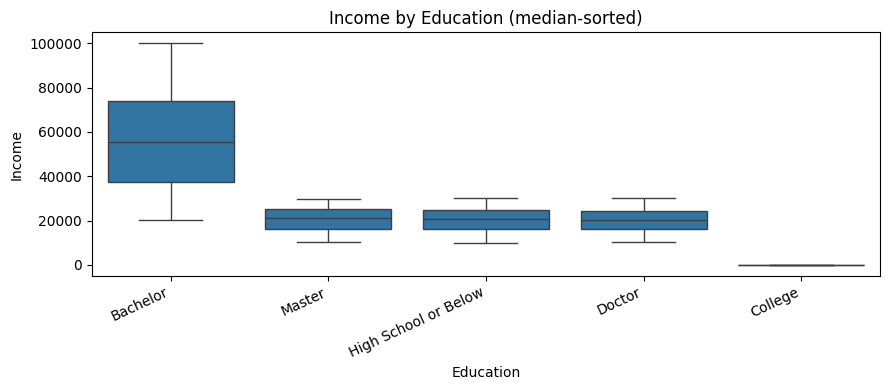

In [ ]:
# Income by education

if set(["Income","Education"]).issubset(dataset.columns):
    # order education by median income (more interpretable)
    med = dataset.groupby("Education")["Income"].median().sort_values(ascending=False)
    plt.figure(figsize=(9,4))
    sns.boxplot(data=dataset, x="Education", y="Income", order=med.index, showfliers=False)
    plt.title("Income by Education (median-sorted)")
    plt.xlabel("Education")
    plt.ylabel("Income")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

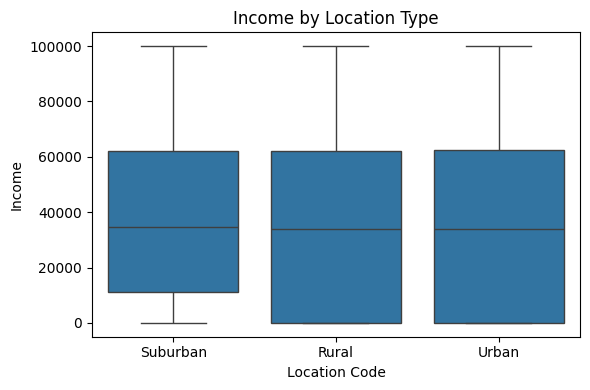

In [ ]:
# Income by location code
if set(["Income","Location Code"]).issubset(dataset.columns):
    order = dataset["Location Code"].value_counts().index
    plt.figure(figsize=(6,4))
    sns.boxplot(data=dataset, x="Location Code", y="Income", order=order, showfliers=False)
    plt.title("Income by Location Type")
    plt.xlabel("Location Code")
    plt.ylabel("Income")
    plt.tight_layout()
    plt.show()

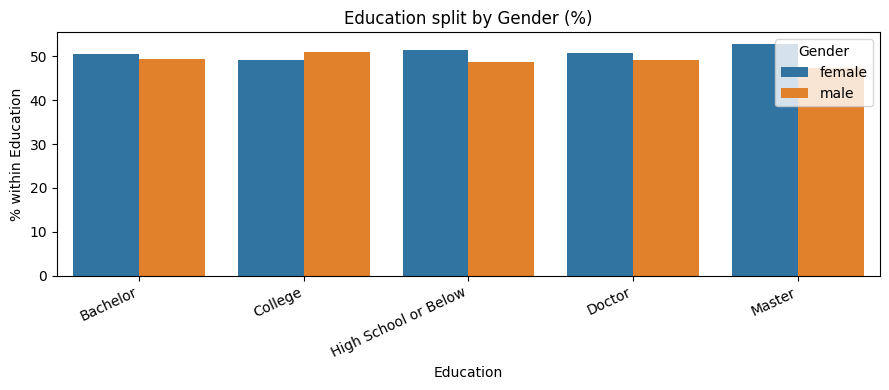

In [ ]:
# Education split by gender

if set(["Education","Gender"]).issubset(dataset.columns):
    edu_gender = (
        dataset.groupby(["Education","Gender"])
        .size()
        .rename("count")
        .reset_index()  # this now keeps both columns safely
    )
    # compute % within each Education group
    edu_gender["pct"] = edu_gender.groupby("Education")["count"].transform(lambda x: x / x.sum() * 100)
    
    order_edu = dataset["Education"].value_counts().index
    plt.figure(figsize=(9,4))
    sns.barplot(data=edu_gender, x="Education", y="pct", hue="Gender", order=order_edu)
    plt.title("Education split by Gender (%)")
    plt.xlabel("Education")
    plt.ylabel("% within Education")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


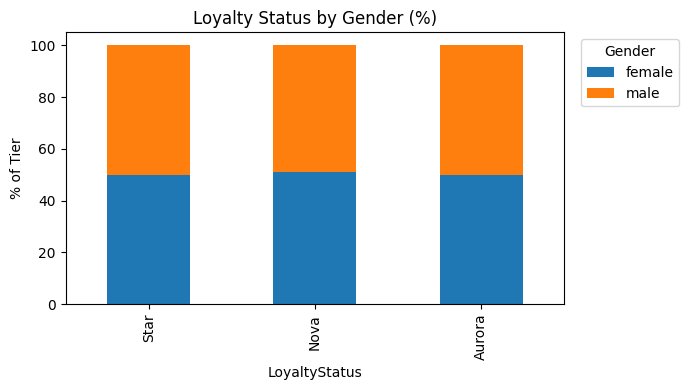

In [ ]:
# loyalty status by gender

if set(["LoyaltyStatus","Gender"]).issubset(dataset.columns):
    ctab = pd.crosstab(dataset["LoyaltyStatus"], dataset["Gender"], normalize="index") * 100
    ctab = ctab.loc[dataset["LoyaltyStatus"].value_counts().index]  # order tiers by size
    ax = ctab.plot(kind="bar", stacked=True, figsize=(7,4))
    plt.title("Loyalty Status by Gender (%)")
    plt.ylabel("% of Tier")
    plt.xlabel("LoyaltyStatus")
    plt.legend(title="Gender", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("LoyaltyStatus and/or Gender columns not found.")

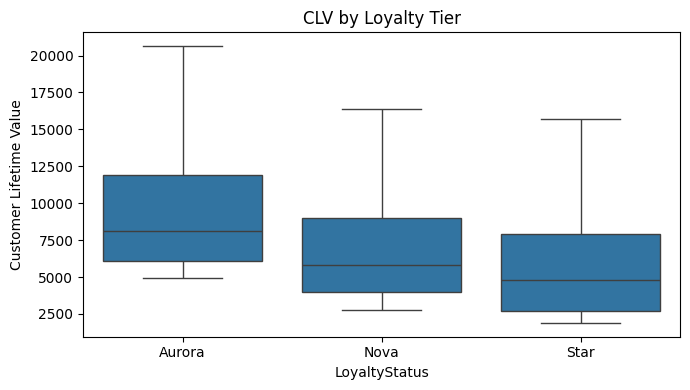

In [ ]:
# CLV by LoyaltyStatus

if set(["Customer Lifetime Value","LoyaltyStatus"]).issubset(dataset.columns):
    order = (dataset.groupby("LoyaltyStatus")["Customer Lifetime Value"]
             .median().sort_values(ascending=False).index)
    plt.figure(figsize=(7,4))
    sns.boxplot(data=dataset, x="LoyaltyStatus", y="Customer Lifetime Value",
                order=order, showfliers=False)
    plt.title("CLV by Loyalty Tier")
    plt.xlabel("LoyaltyStatus")
    plt.ylabel("Customer Lifetime Value")
    plt.tight_layout()
    plt.show()
else:
    print("Customer Lifetime Value and/or LoyaltyStatus columns not found.")

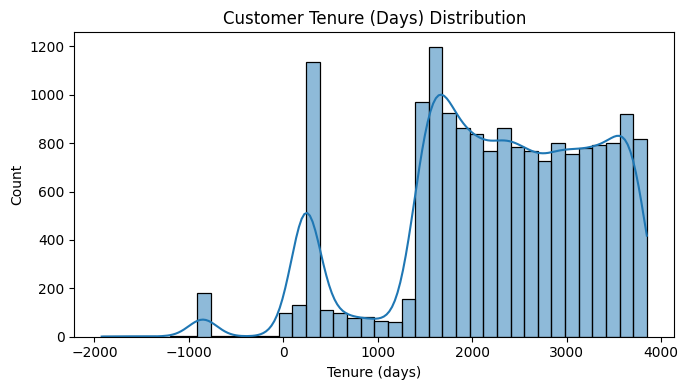

In [ ]:
# Customer tenure distibution

if "CustomerTenureDays" in dataset.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(dataset["CustomerTenureDays"].dropna(), bins=40, kde=True)
    plt.title("Customer Tenure (Days) Distribution")
    plt.xlabel("Tenure (days)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("CustomerTenureDays column not found.")

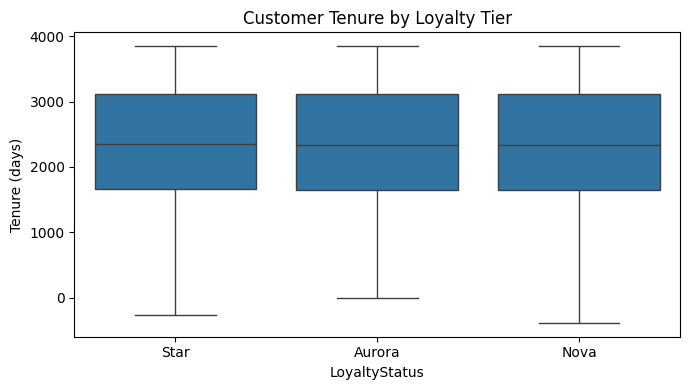

In [ ]:
# Tenure by LoyaltyStatus

if set(["CustomerTenureDays","LoyaltyStatus"]).issubset(dataset.columns):
    order = (dataset.groupby("LoyaltyStatus")["CustomerTenureDays"]
             .median().sort_values(ascending=False).index)
    plt.figure(figsize=(7,4))
    sns.boxplot(data=dataset, x="LoyaltyStatus", y="CustomerTenureDays",
                order=order, showfliers=False)
    plt.title("Customer Tenure by Loyalty Tier")
    plt.xlabel("LoyaltyStatus")
    plt.ylabel("Tenure (days)")
    plt.tight_layout()
    plt.show()
else:
    print("CustomerTenureDays and/or LoyaltyStatus columns not found.")

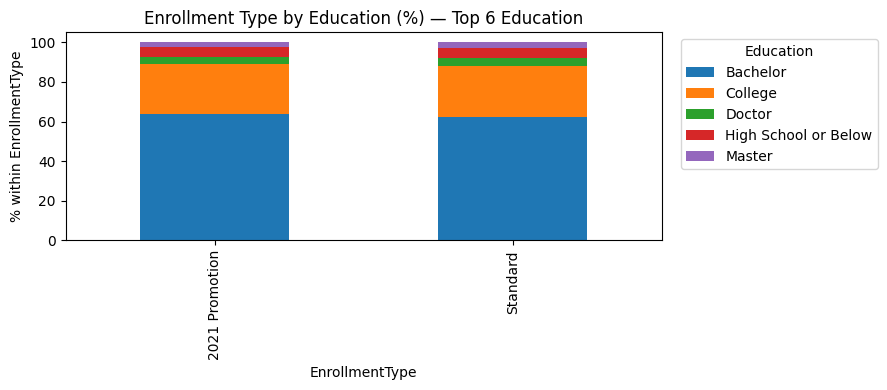

In [ ]:
# EnrollmentType by Education

if set(["EnrollmentType","Education"]).issubset(dataset.columns):
    # limit to top education categories to avoid clutter
    top_edu = dataset["Education"].value_counts().nlargest(6).index
    sub = dataset[dataset["Education"].isin(top_edu)].copy()
    ctab = pd.crosstab(sub["EnrollmentType"], sub["Education"], normalize="index") * 100
    ax = ctab.plot(kind="bar", stacked=True, figsize=(9,4))
    plt.title("Enrollment Type by Education (%) — Top 6 Education")
    plt.ylabel("% within EnrollmentType")
    plt.xlabel("EnrollmentType")
    plt.legend(title="Education", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("EnrollmentType and/or Education columns not found.")

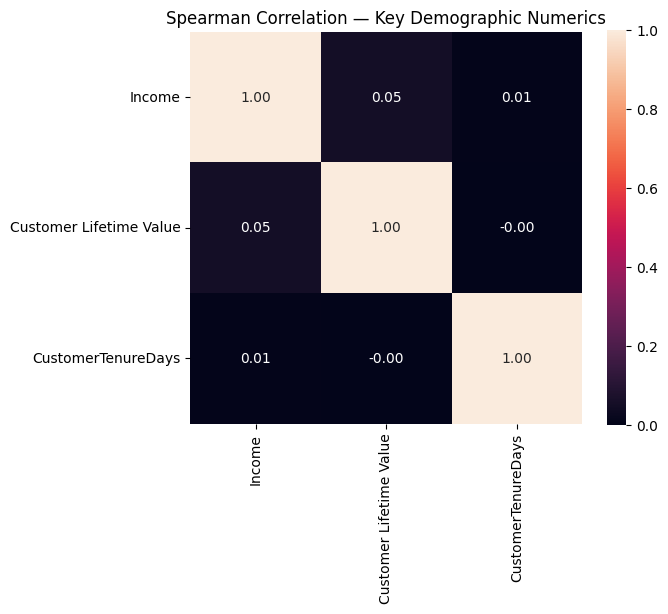

In [ ]:
# Correlation heatmap

num_cols = [c for c in ["Income","Customer Lifetime Value","CustomerTenureDays"] if c in dataset.columns]
if len(num_cols) >= 2:
    plt.figure(figsize=(4+len(num_cols), 3+len(num_cols)))
    corr = dataset[num_cols].corr(method="spearman")
    sns.heatmap(corr, annot=True, fmt=".2f", square=True, cbar=True)
    plt.title("Spearman Correlation — Key Demographic Numerics")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric demographic columns for correlation.")